In [4]:
from google import genai
import os

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

response = client.models.generate_content(
    model="gemini-3.1-pro-preview", 
    contents="Hello from my Jupyter notebook!"
)

print(response.text)

Hello right back to your Jupyter notebook! `print("Hello from the AI!")` 🐍✨

How can I help you today? Are we writing some Python, crunching some data, training a model, or just testing out an API? Let me know what you're working on!


In [5]:
import sys
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Torch CUDA:", torch.version.cuda)

Torch version: 2.2.0+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Torch CUDA: 11.8


In [32]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from jiwer import wer, cer

In [7]:
prompt_text_1 = "Extract all text from this image exactly as written. Preserve line breaks."

In [8]:
prompt_text_2 = """
You are an OCR specialist.

Extract every visible character from this image exactly as it appears.

Return plain text only. Preserve the original reading order, line breaks, paragraph breaks, headings, punctuation, capitalization, spelling, abbreviations, page numbers, and hyphenation exactly as printed.

Do not correct spelling or grammar. Do not modernize, normalize, translate, summarize, explain, or infer missing text. Do not merge words that are split by line-ending hyphens.

If any character or word cannot be read with confidence, write [illegible] exactly at that position instead of guessing.

Do not include any #, comments, Markdown, labels, or additional text. Return only the transcription.
"""

In [13]:
import os
from google import genai
from google.genai import types


def run_ocr_one_image(image_path, prompt_text):
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    response = client.models.generate_content(
        model="gemini-3.1-pro-preview",
        contents=[
            prompt_text,
            types.Part.from_bytes(
                data=image_bytes,
                mime_type="image/jpeg"
            )
        ]
    )

    return response.text

In [14]:
ENG_IMAGES_DIR = "../images_eng"
ENG_GOLD_DIR = "../gold_english"

In [15]:
import os

output_dir = "outputs/Experiment_1"
os.makedirs(output_dir, exist_ok=True)

In [16]:
pages = [1,2,3,4,5,6]

In [17]:
for p in pages:
    print("\n==============================")
    print(f"Page {p}")
    print("==============================")

    image_path = os.path.join(
        ENG_IMAGES_DIR,
        f"{p}.jpg"
    )

    output_path = os.path.join(
        output_dir,
        f"page_{p}.txt"
    )

    output_text = run_ocr_one_image(
        image_path,
        prompt_text_2
    )

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Page 1
Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics

Smart Everything

Uphill battle - Threats posed by AI to online privacy: Is there hope for
having any control over one´s online data trail, when faced by even
better AI profiling tools?

1. Introduction

Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. AI systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences, behaviour,
or interests. These profiling pra

In [18]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [19]:
results_exp1 = []

for p in pages:
    print(f"Evaluating page {p}...")

    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(output_dir, f"page_{p}.txt")

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 1...
Evaluating page 2...
Evaluating page 3...
Evaluating page 4...
Evaluating page 5...
Evaluating page 6...


In [27]:
print("=== Experiment 1 Results: Gemini - English ===")
df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Experiment 1 Results: Gemini - English ===


,page,WER,CER
0,1,0.005063,0.000793
1,2,0.027350,0.004708
2,3,0.037037,0.006046
3,4,0.011494,0.001504
4,5,0.017857,0.002728
5,6,0.009091,0.001459


In [28]:
mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

print("=== Experiment 1 Results - Gemini -English ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Experiment 1 Results - Gemini -English ===
Mean WER: 0.0180
Mean CER: 0.0029


In [29]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

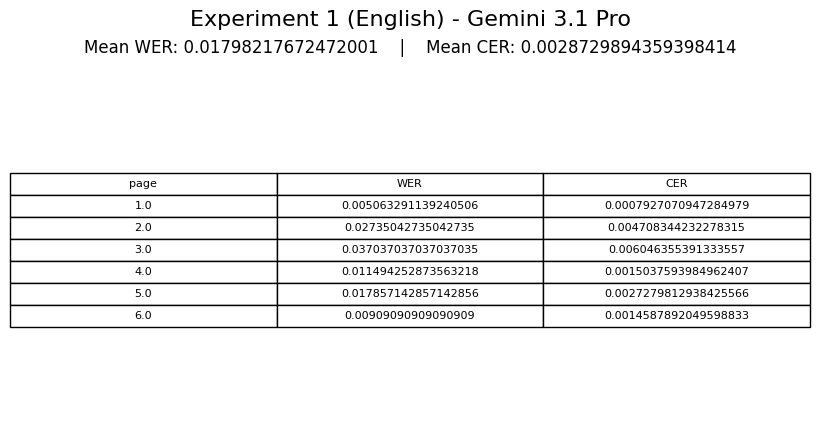

Saved: outputs/Results\experiment_1_gpt_results.png


In [30]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_1_gpt_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp1) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 1 (English) - Gemini 3.1 Pro", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)

# Table
table = ax.table(
    cellText=df_exp1.values,
    colLabels=df_exp1.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

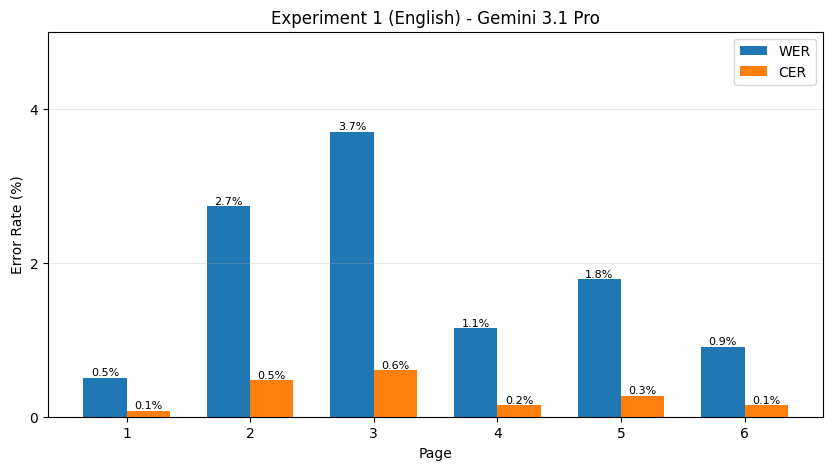

In [33]:
x = np.arange(len(df_exp1))
width = 0.35

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, wer_pct, width, label="WER")
bars2 = plt.bar(x + width/2, cer_pct, width, label="CER")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(x, df_exp1["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - Gemini 3.1 Pro")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 2))

save_path = os.path.join(
    output_dir_result_1,
    "experiment_1_gemini_graph_results.pdf"
)

plt.savefig(save_path, bbox_inches="tight")
plt.show()